In [1]:
# Set up sys.path so that 'src/spindle_dev' is importable as 'spindle_dev'
import sys
import importlib
from pathlib import Path

project_root = '/home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/Projects/spindle_dev'
src_path = Path(project_root) / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import spindle_dev
# Reload to pick up code changes without restarting the kernel
importlib.reload(spindle_dev)

<module 'spindle_dev' from '/home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/__init__.py'>

In [2]:
import scanpy as sc

In [5]:
data_prefix = '/home/NAShome/kaurh2/visium/processed_h5ads_stlearn'
adata = sc.read_h5ad(f'{data_prefix}/SG017_04.h5ad')

In [6]:
adata_raw = sc.read_h5ad('/home/NAShome/kaurh2/visium/raw_h5ads/SG017_04.h5ad')

In [10]:
adata.shape

(9375, 18062)

In [11]:
adata_raw.shape

(9380, 18108)

In [ ]:
adata.X = adata_raw[adata.obs_names, adata.var_names].X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 32654886 stored elements and shape (9375, 18062)>

In [15]:
adata.X = adata.raw.to_adata().X

In [16]:
adata.obs.head()

,in_tissue,array_row,array_col,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,...,imagecol,imagerow,tile_path,leiden_05,leiden_03_ge,leiden_05_ge,leiden_08_ge,leiden_03_morph,leiden_05_morph,leiden_08_morph
AACAATGGAACCACAT-1,1,54,32,877,6.777647,1116.0,7.018402,177.0,5.181784,15.860215,...,3210.190448,1445.714045,/mnt/storage/Desmoplasia_data/Visium/processed...,4,3,2,8,5,4,8
AACAATTATCTGCGCC-1,1,37,219,1190,7.082549,1472.0,7.295056,102.0,4.634729,6.929348,...,1555.900808,1192.904962,/mnt/storage/Desmoplasia_data/Visium/processed...,3,2,5,5,2,3,3
AACACCAGCCTACTCG-1,1,31,39,1220,7.107425,1698.0,7.437795,225.0,5.420535,13.250883,...,3146.759840,1094.140463,/mnt/storage/Desmoplasia_data/Visium/processed...,4,3,2,7,5,4,8
AACACCATACGATAGT-1,1,4,154,8108,9.000730,32610.0,10.392405,1581.0,7.366445,4.848206,...,2128.303127,685.769473,/mnt/storage/Desmoplasia_data/Visium/processed...,5,1,7,6,3,5,11
AACACCATTCGCATAC-1,1,53,139,1885,7.542213,2473.0,7.813591,113.0,4.736198,4.569349,...,2264.205404,1434.494006,/mnt/storage/Desmoplasia_data/Visium/processed...,3,2,5,5,2,3,3


/tmp/ipykernel_871934/2778044729.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["leiden_05"], spot_size=350, img_key=None)


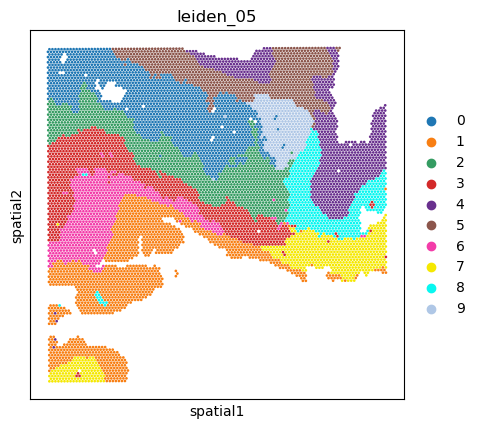

In [24]:
sc.pl.spatial(adata, color=["leiden_05"], spot_size=350, img_key=None)

In [25]:
# Reload spindle_dev metrics, index, and package after code changes
import importlib
import spindle_dev
import spindle_dev.metrics as metrics
import spindle_dev.index as index
import spindle_dev.preprocessing as preprocessing
import spindle_dev.plotting as plotting

# Reload in dependency order so new symbols are available
importlib.reload(metrics)
importlib.reload(index)
importlib.reload(preprocessing)
importlib.reload(plotting)
importlib.reload(spindle_dev)
import spindle_dev.typing as typing
importlib.reload(typing)
import spindle_dev.test as test
import spindle_dev.search as search
importlib.reload(test)
importlib.reload(search)

<module 'spindle_dev.search' from '/home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/search.py'>

In [26]:
import numpy as np
import pandas as pd

In [39]:
def prepare_to_index(adata, resolution=0.2, min_final_size=20,num_genes=None,max_pts=20):
    coords = adata.obsm["spatial"]
    tiles = preprocessing.build_quadtree_tiles(coords, max_pts=max_pts, min_side=0.0, max_depth=40)
    if num_genes is None:
        num_genes = adata.n_vars
    genes_work, gene_idx = spindle_dev.preprocessing.topvar_genes(adata, G=num_genes)  
    tile_covs = spindle_dev.preprocessing.build_tile_covs_full(adata, tiles, gene_idx, n_jobs=8, eps=1e-6)
    data = index.ProcessedData(tiles, tile_covs, genes_work, adata.n_obs)
    data.reduce_dim(num_pca_components=30, n_components=2, do_umap=True)
    data.cluster_spds(cluster_distance="tree", cluster_method="leiden", resolution=resolution)
    data.assign_label_to_spots()
    data.get_corr_mean_by_cluster()
    out_dict = data.get_adaptive_runs(find_blocks=True, with_size_guard=True,min_final_size=min_final_size,max_final_size=100)
    return tiles, tile_covs, genes_work, data, out_dict

In [44]:
tiles, tile_covs, genes_work, data, out_dict = prepare_to_index(adata, min_final_size=5,num_genes=400, resolution=0.2,max_pts=20)

[2026-04-01 18:35:56,097] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.
[2026-04-01 18:35:56,098] INFO spindle_dev.index: Building ultrametric features from SPD matrices.
/home/NAS/sarkah1/miniforge3/envs/spatial_cpu/lib/python3.12/site-packages/scipy/cluster/hierarchy.py:1715: RuntimeWarning: invalid value encountered in scalar divide
  c = xp.sum(numerator) / xp.sqrt(xp.sum(denomA) * xp.sum(denomB))
[2026-04-01 18:35:57,926] INFO spindle_dev.index: Computing latent features from the tree representations.
[2026-04-01 18:35:58,059] INFO spindle_dev.index: Reducing latent features to 30 dimensions using PCA.
[2026-04-01 18:35:58,759] INFO spindle_dev.index: Explained variance ratios by PCA components: [0.1608951  0.05127228 0.02626324 0.01878755 0.01378491 0.01244538
 0.0113993  0.01125006 0.01075696 0.01048122 0.00990422 0.00936096
 0.00870075 0.00811411 0.00782791 0.00747987 0.00735063 0.00697484
 0.0063756  0.00595362 0.00577408 0.00566951 0.00553688 0.00498267
 0.0

In [45]:
data.spd_matrices.shape

(715, 400, 400)

In [46]:
import matplotlib.pylab as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

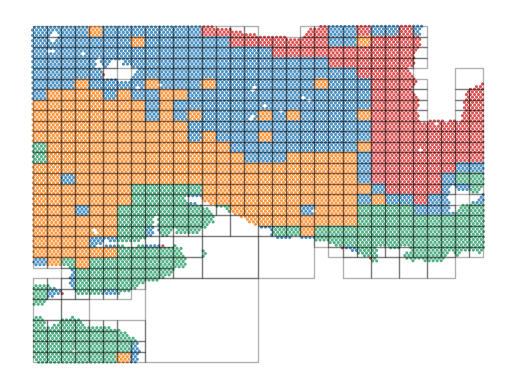

In [47]:
import numpy as np
palette = sc.pl.palettes.default_20
point_colors = [palette[lab] for lab in data.spot_label.values()]
labels = data.labels
indices = np.array([int(i) for i in data.spot_label.keys()])
coords = adata.obsm['spatial']
plt.scatter(coords[indices,0], coords[indices,1], s=5, c=point_colors, lw=0, alpha=0.8)
patches = []
for t in tiles:
    bbox = t.bbox if hasattr(t, "bbox") else t["bbox"]  # (xmin,ymin,xmax,ymax)
    x0, y0, x1, y1 = bbox
    patches.append(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False))
pc = PatchCollection(patches, match_original=True, linewidths=0.2, edgecolors='b', alpha=0.3)
# add collection
ax = plt.gca()
ax.add_collection(pc)
ax.invert_yaxis()
ax.axis('off')

#plt.savefig(f"{result_dir}/spatial_plot_with_cluster.png", dpi=300)
plt.show()

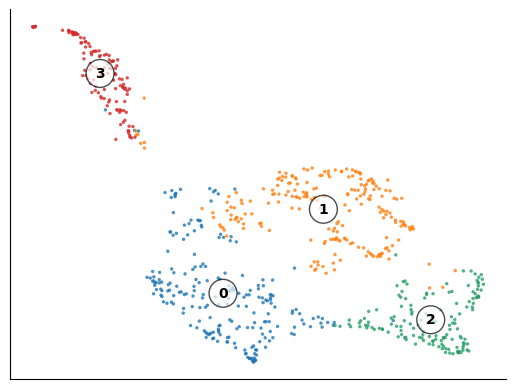

In [49]:
# Create colors for clusters
import numpy as np
import matplotlib.pyplot as plt
n_clusters = len(set(data.labels))
# Use Scanpy's default_20 palette for consistency
palette = sc.pl.palettes.default_20
cluster_colors = [palette[lab] for lab in data.labels]
plt.scatter(data.latent['umap'][:,0], data.latent['umap'][:,1], s=6, lw=0, alpha=0.8, c=cluster_colors)
# Write label on the plot
# with backgrond circle for better visibility
# and bold font
for i in range(n_clusters):
    cluster_points = data.latent['umap'][data.labels == i]
    if len(cluster_points) == 0:
        continue
    x_mean = np.mean(cluster_points[:,0])
    y_mean = np.mean(cluster_points[:,1])
    plt.text(x_mean, y_mean, str(i), color='black', fontsize=10, ha='center', va='center', fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='circle,pad=0.5', alpha=0.7))
# take away top and right border
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# remove axis ticks
ax.set_xticks([])
ax.set_yticks([])
#plt.savefig(f"{result_dir}/umap_plot_with_cluster_labels.png", dpi=300)
plt.show()

In [50]:
epsilon_block_wise_dict = {}
epsilon_dict = {}
for cluster_id in set(data.labels):
    eps_per_block, eps_elbow_per_block, eps = index.choose_adaptive_epsilons(data, cluster_id, k_target_per_block=64)
    epsilon_block_wise_dict[int(cluster_id)] = eps_elbow_per_block
    epsilon_dict[int(cluster_id)] = eps

In [51]:
config = typing.IndexConfig()
config.epsilon_dict = epsilon_dict
config.epsilon_block_wise_dict = epsilon_block_wise_dict
config.threshold_type = 'constant'
config.kmean_method = 'epsilon_net'

In [52]:
# Create index 
dag_dict, stat, dist_list = index.index_spds(data, config=config)

[2026-04-01 18:36:41,465] INFO spindle_dev.index: Processing cluster 0
[2026-04-01 18:36:41,466] INFO spindle_dev.index: Building SPD index with epsilon=5.49303189380736
[2026-04-01 18:36:41,467] INFO spindle_dev.index: Step 1: Cluster blocks within each class of SPD matrices.
[2026-04-01 18:36:41,475] INFO spindle_dev.index: Cluster 0: 225 SPDs, 66 blocks
[2026-04-01 18:36:41,475] INFO spindle_dev.index:  Using epsilon-net clustering for block 0
[2026-04-01 18:36:41,517] INFO spindle_dev.index:  Finished block 0 in 0.04 seconds, found 14 clusters.
[2026-04-01 18:36:41,517] INFO spindle_dev.index:  Using epsilon-net clustering for block 1
[2026-04-01 18:36:41,548] INFO spindle_dev.index:  Finished block 1 in 0.03 seconds, found 19 clusters.
[2026-04-01 18:36:41,548] INFO spindle_dev.index:  Using epsilon-net clustering for block 2
[2026-04-01 18:36:41,563] INFO spindle_dev.index:  Finished block 2 in 0.02 seconds, found 11 clusters.
[2026-04-01 18:36:41,563] INFO spindle_dev.index:  Us

In [53]:
score_list = []
for cluster_id in set(data.labels):
    cluster_dag = dag_dict[cluster_id]
    cluster_score = index.score_nodes_from_a_cluster(data, cluster_id, dag_dict, take_representative_mean=True)
    score_list.extend(cluster_score)

100%|██████████| 248/248 [00:00<00:00, 264.48it/s] 


In [57]:
import pandas as pd
def get_dag_stats(dag_dict):
    dag_stats = []
    for cluster_id, cluster_dag in dag_dict.items():
        block_to_node = cluster_dag.block_to_node_indices
        for node in cluster_dag.nodes:
            
            num_spds = len(node.metadata.members)
            block_size = node.metadata.mean.shape[0]
            block_id = node.block_index
            radius = node.metadata.radius
            
            #print(f"Cluster_id {cluster_id} Node id {node.global_node_id} Block {block_id}: {num_spds} spds")
            dag_stats.append({
                "cluster_id": cluster_id,
                "node_id": node.global_node_id,
                "block_id": block_id,
                "block_cluster_id": node.block_cluster_id,
                "num_spds": num_spds,
                "radius": radius,
                "block_size": block_size
            })
    dag_stats_df = pd.DataFrame(dag_stats)
    return dag_stats_df

In [58]:
dag_stats_df = get_dag_stats(dag_dict)

In [54]:
node_scores = []
for node_score in score_list:
    node_scores.append({
        "cluster_id": node_score["cluster_id"],
        "block_id": node_score["block_id"],
        "node_id": node_score["node_id"],
        "node_score": node_score["node_score"],
        "num_spds": node_score["num_spds"],
        "block_size": node_score["block_size"],
        "E": node_score["E"],
        "Q": node_score["Q"],
        "S": node_score["S"],
        "num_modules": len(node_score["modules"])
    })
node_score_df = pd.DataFrame(node_scores)


In [60]:
# for each cluster_id find the top 5 nodes
node_score_df.groupby('cluster_id').apply(lambda df: df.sort_values(by='node_score', ascending=False).head(5))
#node_score_df.sort_values(by='node_score', ascending=False).head(20)

/tmp/ipykernel_871934/2883714191.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  node_score_df.groupby('cluster_id').apply(lambda df: df.sort_values(by='node_score', ascending=False).head(5))


cluster_id  block_id  node_id  node_score  num_spds  \
cluster_id                                                             
0          699            0        65      699    0.301491         1   
           691            0        65      691    0.290417         1   
           679            0        65      679    0.262356         1   
           505            0        65      505    0.233344         1   
           592            0        65      592    0.221388         1   
1          941            1        45      240    0.204257         1   
           1107           1        45      406    0.199794         1   
           1100           1        45      399    0.174771         1   
           1004           1        45      303    0.167809         1   
           995            1        45      294    0.166727         1   
2          1695           2        54      349    0.159145         1   
           1784           2        58      438    0.146091         1   
           1751           2        57      405    0.142100         1   
           1915           2        58      569    0.138460         1   
           1858           2        58      512    0.132297         1   
3          2182           3        69      229    0.206279         3   
           2160           3        69      207    0.193772         1   
           2200           3        69      247    0.192971         3   
           2199           3        69      246    0.184904         1   
           2151           3        69      198    0.178607         2   

                 block_size         E         Q         S  num_modules  
cluster_id                                                              
0          699           43  3.628605  0.167629  0.504340            3  
           691           43  3.262854  0.165047  0.460722            2  
           679           43  3.364857  0.150816  0.483021            2  
           505           43  1.925314  0.201575  0.398746            5  
           592           43  2.223533  0.178288  0.441549            2  
1          941           46  2.657570  0.167277  0.540534            2  
           1107          46  2.199701  0.159381  0.430126            3  
           1100          46  2.216147  0.139399  0.434272            3  
           1004          46  2.154890  0.136083  0.427754            3  
           995           46  2.039456  0.138679  0.410508            3  
2          1695           7  1.604668  0.268739  0.630958            2  
           1784          23  1.944550  0.150125  0.499564            3  
           1751          16  1.753935  0.197864  0.590540            2  
           1915          23  2.114596  0.145756  0.550772            3  
           1858          23  1.994149  0.140586  0.528101            3  
3          2182          40  2.857881  0.149446  0.517026            2  
           2160          40  2.713913  0.161985  0.559224            2  
           2200          40  2.685635  0.142716  0.496534            3  
           2199          40  2.444792  0.151109  0.499491            2  
           2151          40  2.871032  0.134528  0.537574            3

Creating combined figure for cluster 0, node 699, block 65


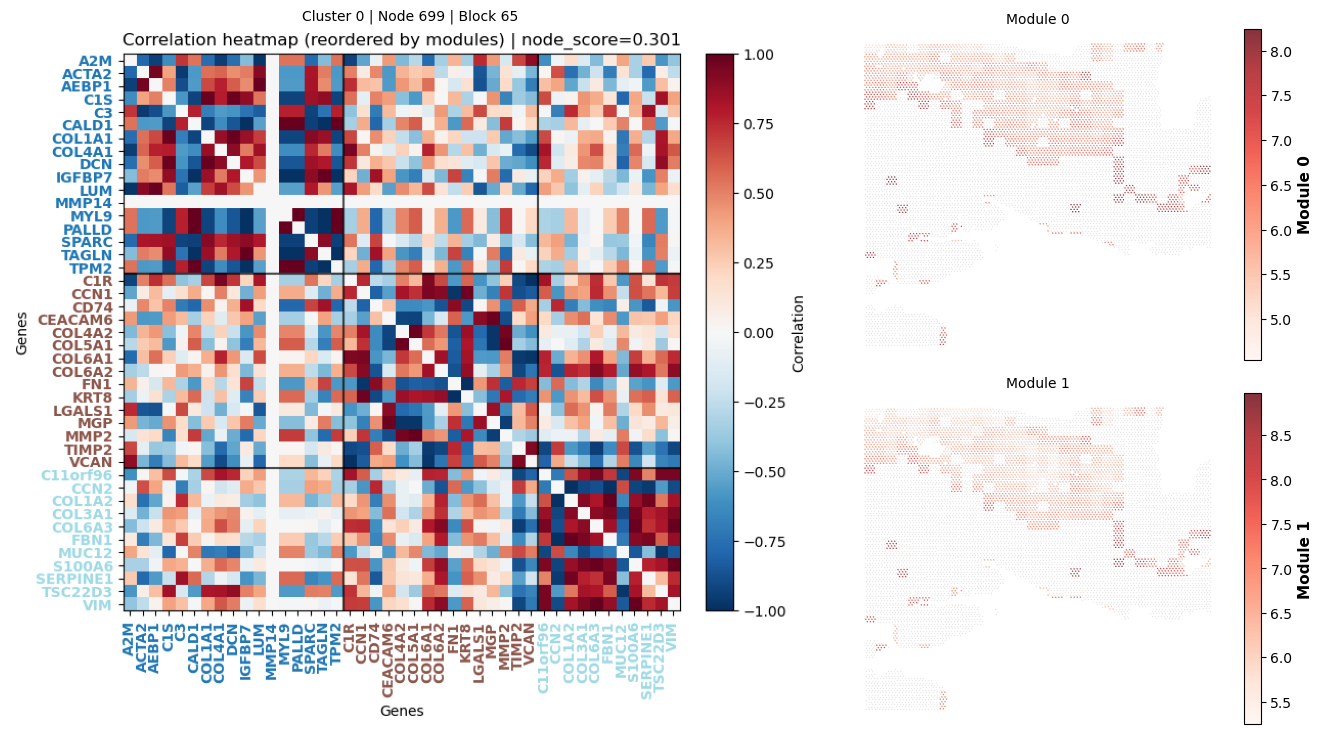

In [64]:
id = 699
scores_846, fig_846 = plotting.plot_module_heatmap_plus_spatial(
    id,
    score_list,
    node_score_df,
    dag_stats_df,
    dag_dict,
    data,
    adata
)

In [66]:
out_846 = go_score.enrich_modules_with_gseapy(score_list[id]['modules'],organism='human')

  Module 0: enrichment completed with 333 terms
  Module 1: enrichment completed with 315 terms
  Module 2: enrichment completed with 257 terms


['A2M', 'ACTA2', 'AEBP1', 'C1S', 'C3', 'CALD1', 'COL1A1', 'COL4A1', 'DCN', 'IGFBP7', 'LUM', 'MMP14', 'MYL9', 'PALLD', 'SPARC', 'TAGLN', 'TPM2']


/home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/go_score.py:519: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


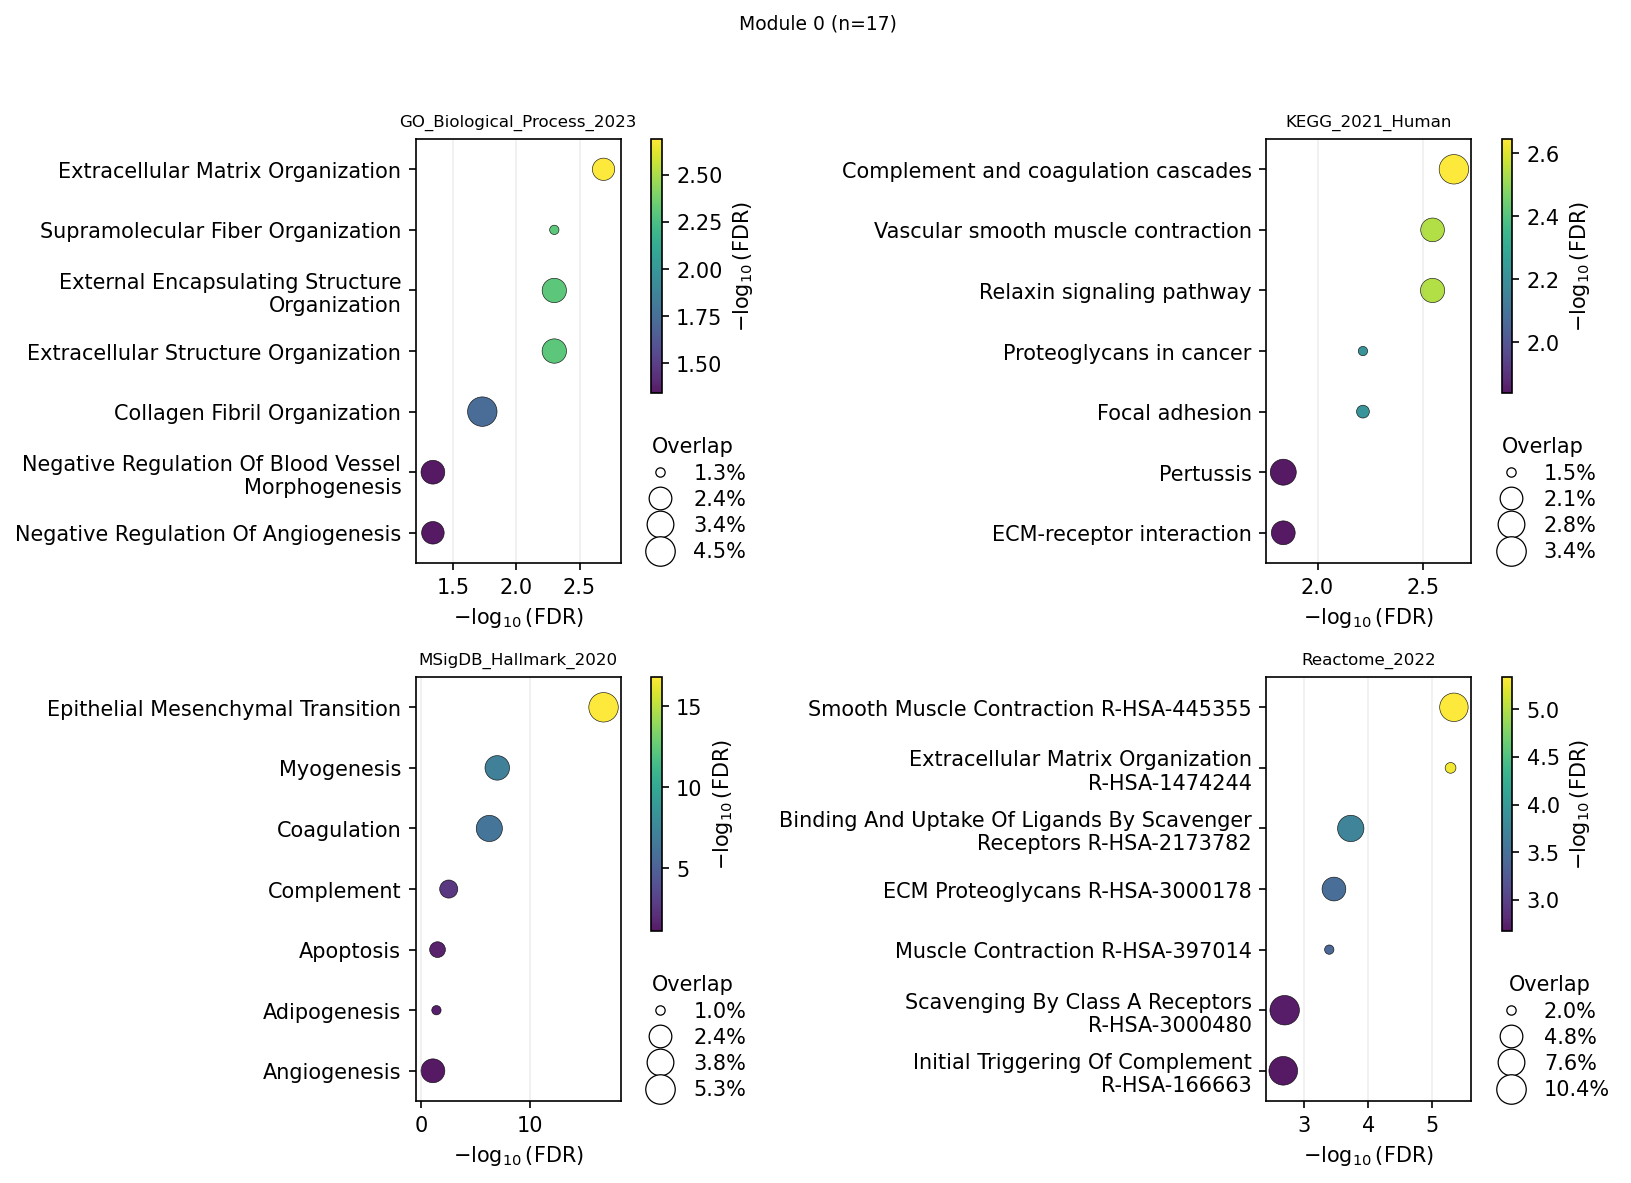

In [68]:
for module_id, module_genes, res in out_846:
    if module_id == 0:
        print(module_genes)
        fig, axes = go_score.plot_module_enrichment_libraries_2(
            module_id=module_id,
            module_genes=module_genes,
            res=res,
            top_n=7,
            ncols=2,
            bar_color="#D41515EE",   # pick your color
            tick_fontsize=10,
            label_fontsize=10,
            title_fontsize=8,
            compact_height_per_term=0.2,
            min_fig_h=8,
            plot_kind="dot",
            size_range=(20, 200),
            use_constrained_layout=False,
            #save_dir=f"{result_dir}/go_enrichment/enrichment_{id}"
        )
        if fig is not None:
            plt.show()

In [63]:
from spindle_dev import go_score

Creating combined figure for cluster 1, node 240, block 45


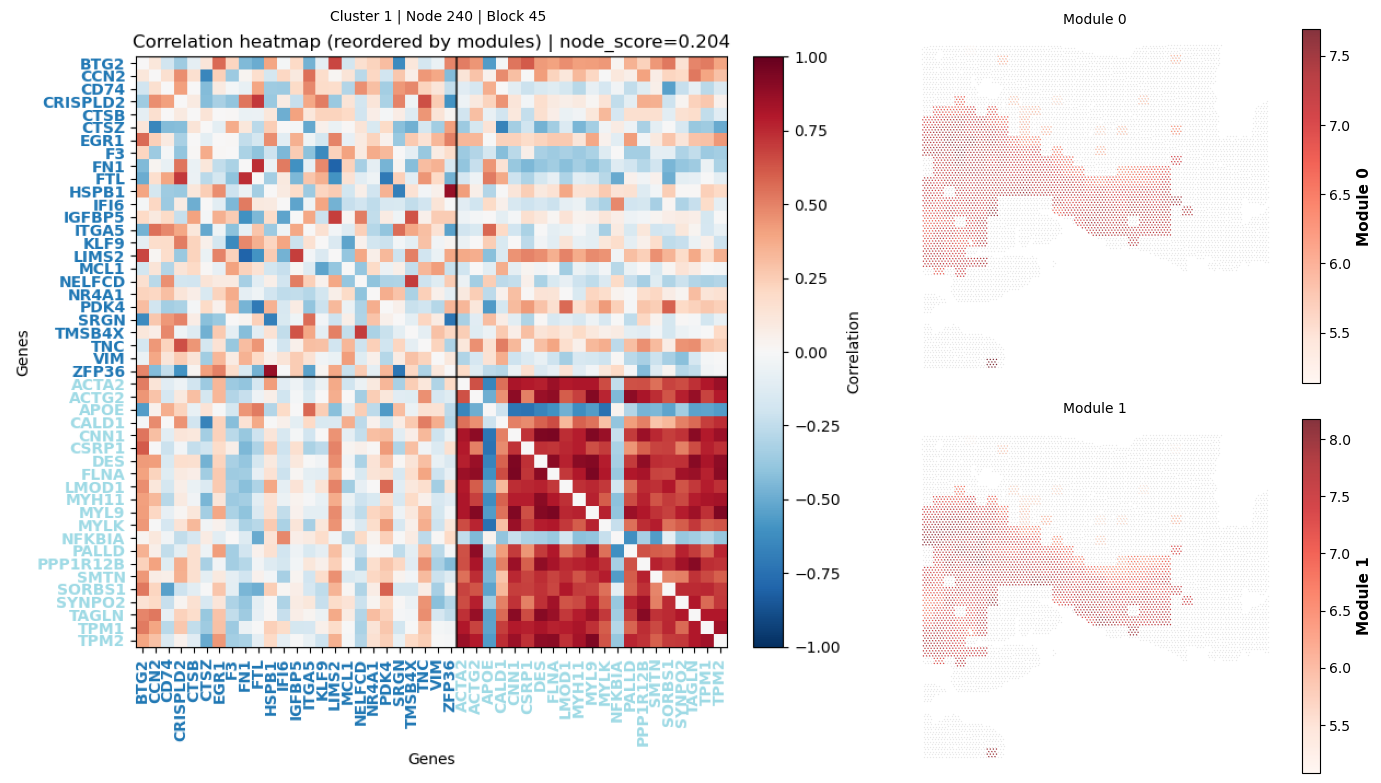

In [61]:
id = 941
scores_846, fig_846 = plotting.plot_module_heatmap_plus_spatial(
    id,
    score_list,
    node_score_df,
    dag_stats_df,
    dag_dict,
    data,
    adata
)